In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")

SEED = 42
REVIEW_FRACTION = 0.02

In [3]:
df = pd.read_csv("Loan_Aprroval.csv")

df["Application_Date"] = pd.to_datetime(df["Application_Date"])

print("Dataset shape:", df.shape)

Dataset shape: (160000, 27)


C:\Users\ISHWAR\AppData\Local\Temp\ipykernel_20116\3165483259.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Application_Date"] = pd.to_datetime(df["Application_Date"])


In [4]:
train = df[df["Application_Date"] < "2026-01-01"].copy()

validation = df[
    (df["Application_Date"] >= "2026-01-01") &
    (df["Application_Date"] < "2026-05-01")
].copy()

test = df[df["Application_Date"] >= "2026-05-01"].copy()

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 119865
Validation: 19684
Test: 20451


In [5]:
cols = [
    "Applicant_Income",
    "Loan_Amount",
    "Credit_Score",
    "DTI_Ratio",
    "Savings",
    "Collateral_Value"
]

df[cols].describe()

,Applicant_Income,Loan_Amount,Credit_Score,DTI_Ratio,Savings,Collateral_Value
count,1.592390e+05,1.600000e+05,158494.00000,156529.000000,1.558390e+05,1.590270e+05
mean,5.194790e+04,1.380463e+06,762.34578,0.541854,2.112765e+05,1.421995e+06
std,4.909798e+04,2.049891e+06,54.98367,0.328995,3.939662e+05,2.776430e+06
min,1.500000e+03,2.500000e+04,485.00000,0.022700,1.532900e+02,0.000000e+00
25%,2.555000e+04,3.180000e+05,726.00000,0.306400,4.465124e+04,0.000000e+00
50%,4.078000e+04,6.852500e+05,764.00000,0.477600,1.031690e+05,3.811000e+05
75%,6.420000e+04,1.559100e+06,800.00000,0.699500,2.322858e+05,1.625750e+06
max,1.686850e+06,2.500000e+07,900.00000,4.607900,2.820197e+07,4.521370e+07


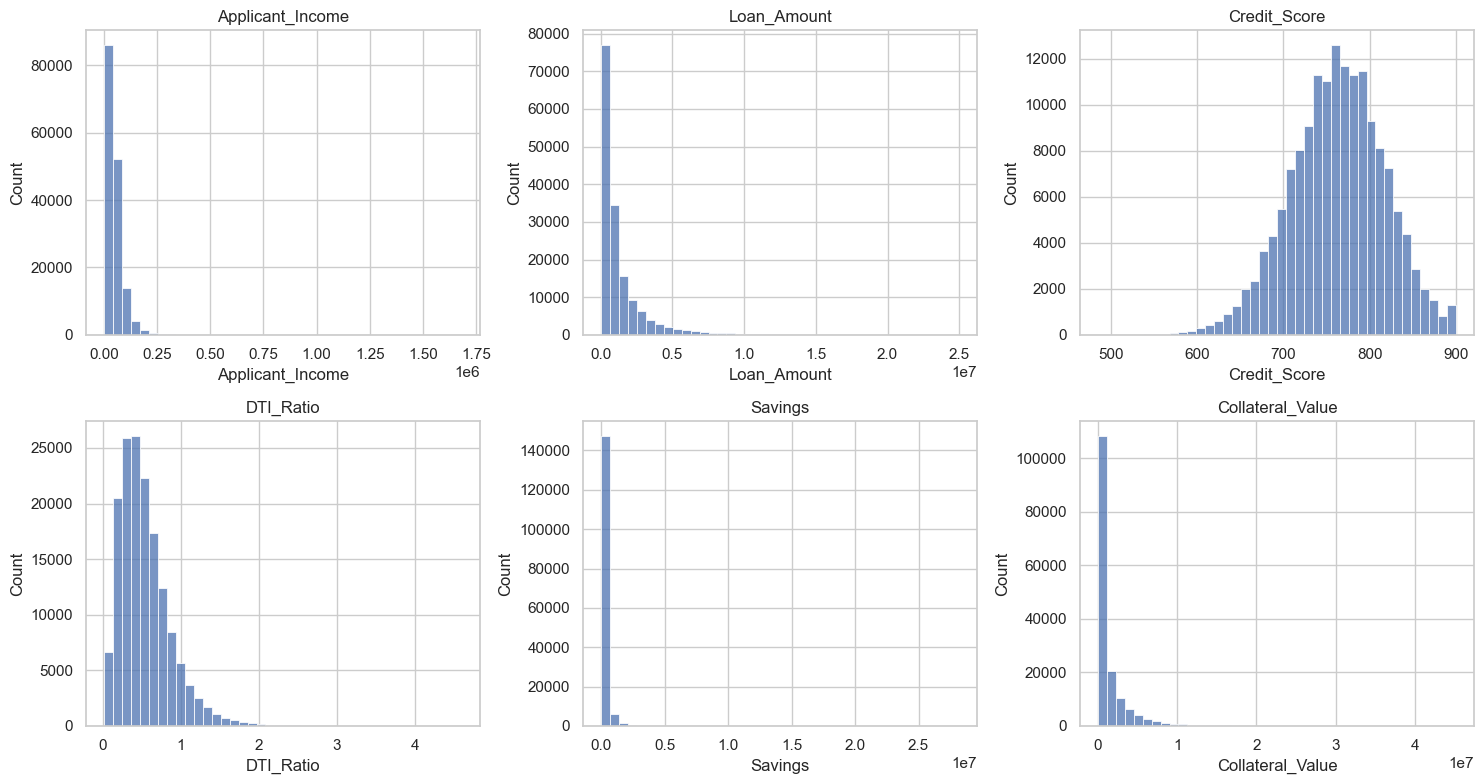

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, ax in zip(cols, axes.ravel()):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [7]:
def make_features(data):

    income = data["Applicant_Income"] + data["Coapplicant_Income"]

    loan = data["Loan_Amount"]

    features = pd.DataFrame(index=data.index)

    features["Income"] = np.log1p(income)
    features["Loan_Amount"] = np.log1p(loan)

    features["Credit_Score"] = data["Credit_Score"]
    features["Existing_Loans"] = data["Existing_Loans"]
    features["DTI_Ratio"] = data["DTI_Ratio"]
    features["Late_Payments"] = data["Late_Payments_12M"]
    features["Credit_History"] = data["Credit_History_Years"]
    features["Loan_Term"] = data["Loan_Term"]

    features["Loan_to_Income"] = loan / (income * 12)

    features["Savings_Ratio"] = data["Savings"] / income

    features["Collateral_Ratio"] = (
        data["Collateral_Value"] / loan
    )

    features = features.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return features

In [8]:
X_train = make_features(train)
X_validation = make_features(validation)
X_test = make_features(test)

print("Features:", X_train.shape[1])

Features: 11


In [9]:
model = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),

    ("isolation_forest", IsolationForest(
        n_estimators=200,
        max_samples=512,
        contamination="auto",
        random_state=42,
        n_jobs=2
    ))
])

model.fit(X_train)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [10]:
validation_scores = -model.score_samples(X_validation)

print(
    "Lowest score:",
    round(validation_scores.min(), 4)
)

print(
    "Highest score:",
    round(validation_scores.max(), 4)
)

Lowest score: 0.3652
Highest score: 0.6826


In [11]:
threshold = np.quantile(
    validation_scores,
    1 - REVIEW_FRACTION
)

print("Review threshold:", round(threshold, 5))

print(
    "Validation review rate:",
    f"{(validation_scores >= threshold).mean():.2%}"
)

Review threshold: 0.5573
Validation review rate: 2.00%


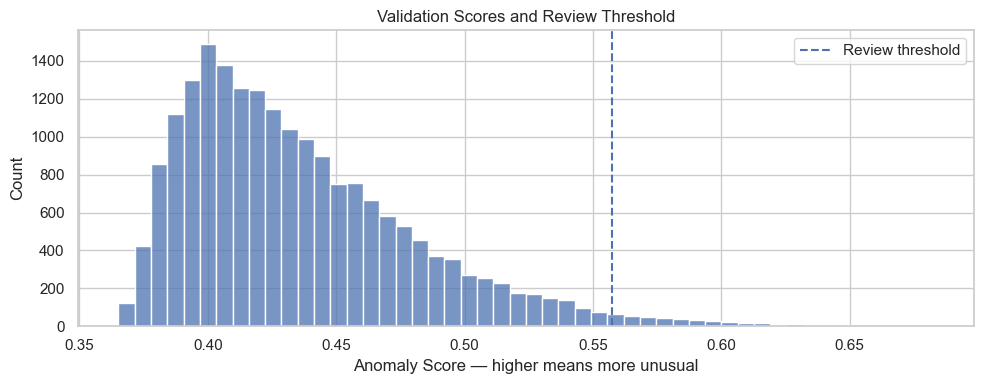

In [12]:
plt.figure(figsize=(10, 4))

sns.histplot(
    validation_scores,
    bins=50
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Review threshold"
)

plt.xlabel("Anomaly Score — higher means more unusual")
plt.ylabel("Count")

plt.title(
    "Validation Scores and Review Threshold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [13]:
test_scores = -model.score_samples(X_test)

test_flags = test_scores >= threshold

print("Test applications:", len(test))
print("Applications for review:", test_flags.sum())
print(
    "Test review rate:",
    f"{test_flags.mean():.2%}"
)

Test applications: 20451
Applications for review: 416
Test review rate: 2.03%


In [14]:
results = test[
    [
        "Applicant_ID",
        "Loan_Purpose",
        "Applicant_Income",
        "Loan_Amount",
        "Credit_Score",
        "DTI_Ratio"
    ]
].copy()

results["Anomaly_Score"] = test_scores

results["Review_Flag"] = test_flags

results["Review_Status"] = np.where(
    test_flags,
    "Manual review",
    "No anomaly flag"
)

print("Final test results created.")

Final test results created.


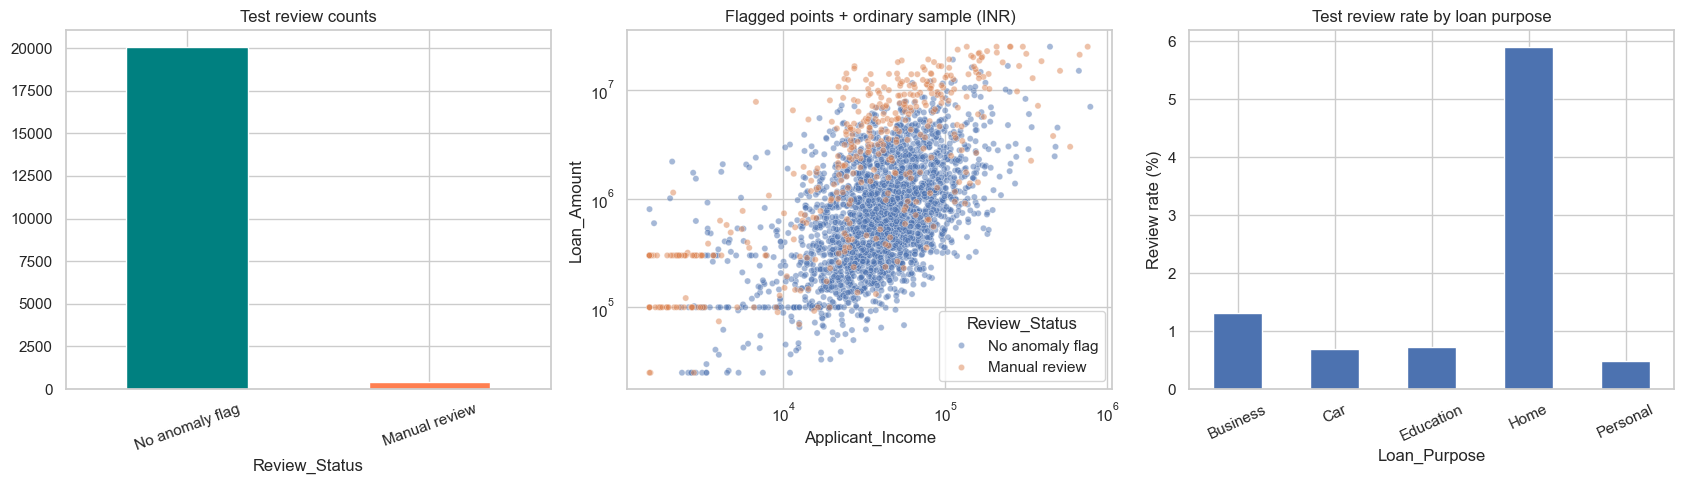

In [15]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 5)
)


# 1. Review counts

results["Review_Status"].value_counts().plot.bar(
    ax=axes[0],
    color=["teal", "coral"]
)

axes[0].set_title("Test review counts")
axes[0].tick_params(axis="x", rotation=20)


# 2. Flagged applications + normal sample

normal = results[results["Review_Flag"] == False]

flagged = results[results["Review_Flag"] == True]

normal_sample = normal.sample(
    min(2500, len(normal)),
    random_state=42
)

plot_data = pd.concat([
    normal_sample,
    flagged
])

sns.scatterplot(
    data=plot_data,
    x="Applicant_Income",
    y="Loan_Amount",
    hue="Review_Status",
    alpha=0.5,
    s=20,
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_yscale("log")

axes[1].set_title(
    "Flagged points + ordinary sample (INR)"
)


# 3. Review rate by loan purpose

review_rate = (
    results.groupby("Loan_Purpose")["Review_Flag"]
    .mean() * 100
)

review_rate.plot.bar(
    ax=axes[2]
)

axes[2].set_title(
    "Test review rate by loan purpose"
)

axes[2].set_ylabel(
    "Review rate (%)"
)

axes[2].tick_params(
    axis="x",
    rotation=25
)


plt.tight_layout()
plt.show()

In [16]:
from pathlib import Path
import json
import joblib
import platform
from importlib.metadata import version

out = Path("fintrust_models")
out.mkdir(exist_ok=True)

raw_columns = [
    "Applicant_Income", "Coapplicant_Income", "Loan_Amount",
    "Credit_Score", "Existing_Loans", "DTI_Ratio",
    "Late_Payments_12M", "Credit_History_Years",
    "Loan_Term", "Savings", "Collateral_Value"
]

metadata = {
    "model_name": "Isolation Forest",
    "model_version": "isolation_v1",
    "raw_columns": raw_columns,
    "feature_columns": X_train.columns.tolist(),
    "threshold": float(threshold),
    "score_definition": "-pipeline.score_samples",
    "review_rule": "anomaly_score >= threshold",
    "validation_review_fraction": float(REVIEW_FRACTION),
    "python_version": platform.python_version(),
    "packages": {
        p: version(p)
        for p in ["scikit-learn", "numpy", "pandas", "joblib"]
    }
}

joblib.dump(
    {"pipeline": model, "metadata": metadata},
    out / "isolation_model.joblib"
)
(out / "isolation_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

sample_raw = test.iloc[:10][raw_columns]
sample_features = make_features(sample_raw)
scores = -model.score_samples(sample_features)

fixtures = {
    "raw_inputs": json.loads(sample_raw.to_json(orient="records")),
    "expected_anomaly_scores": scores.tolist(),
    "expected_review_flags": (scores >= threshold).tolist()
}
(out / "isolation_test_cases.json").write_text(
    json.dumps(fixtures, indent=2), encoding="utf-8"
)

loaded = joblib.load(out / "isolation_model.joblib")
np.testing.assert_allclose(
    -loaded["pipeline"].score_samples(sample_features), scores
)
print("Isolation Forest exported and reload verified:", out.resolve())

Isolation Forest exported and reload verified: D:\Ml_cp\fintrust_models
